### Part 1: Loading dataset (14 points)

##### Please go to Blackboard, under the Week8 Midterm Exam folder, download the dataset, WineData.xlsx, and load the dataset (hint: pd.read_excel()) into your Python Jupyter notebook environment. (5 points)

In [25]:
import pandas as pd # need package to read datasets
import numpy as np # need package to perform basic analytics

In [26]:
data = pd.read_excel('WineData.xlsx') # open the dataset
data # see the dataset to investigate

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,red,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,red,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,red,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,white,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
6493,white,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
6494,white,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
6495,white,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


##### Please show/print the shape of the dataset (hint: shape()). (3 points)

In [27]:
data.shape # shape of dataset

(6497, 13)

##### Please show/print the first 5 rows of the dataset (hint: head()). (3 points)

In [28]:
data.head() # first 5 rows of dataset

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,red,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,red,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,red,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


##### Please show/print the column names in a list (hint: df.columns.tolist()). (3 points)

In [29]:
data.columns.tolist() # list of all column names

['type',
 'fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

### Part 2: Data Understanding (14 + 5 points)

##### Please create visualizations to better understand the data. Please create two plots along with descriptions/storytelling using your plots. (5+5+2+2 points)

In [30]:
import matplotlib.pyplot as plt # need this for plots

Text(0, 0.5, 'Count')

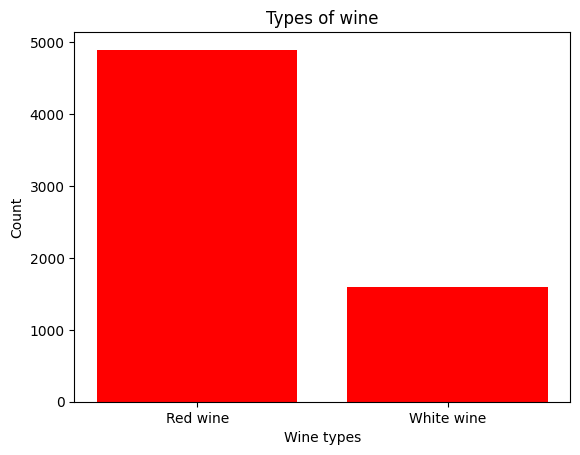

In [31]:
# Bar chart that shows the total counts of wine types

column_1 = data['type'].value_counts() # creates a count of categorical data which are the wine types
wine_t = ['Red wine', 'White wine'] # wine types so red and white
wine_c = [4898,1599] # the total counts between each type, red first then white

plt.bar(wine_t,wine_c,color='red') # plot a bar chart showcasing red and white, setting the color to be red
plt.title('Types of wine') # title of bar chart
plt.xlabel('Wine types') # x axis of bar chart
plt.ylabel('Count') # y axis of bar chart

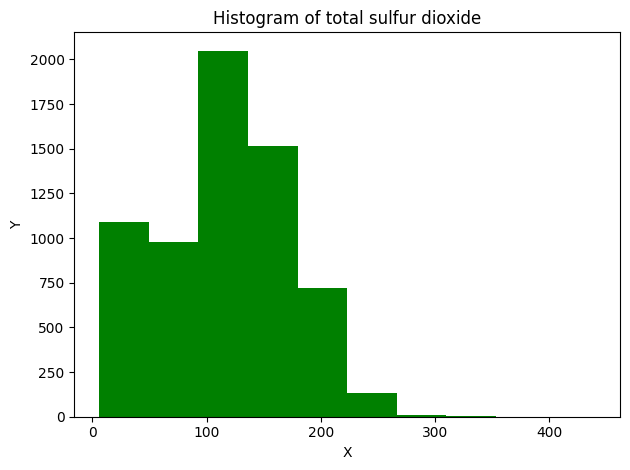

In [32]:
# Histogram of total sulfur dioxide 
sulfur_dioxide_array = data['total sulfur dioxide'].values # convert the data column of total sulfur dioxide into array for manipulation

plt.figure() # basic figure for plot
plt.hist(sulfur_dioxide_array,bins=10,color='green') # histogram of sulfur dioxide, 10 bins and set the color green
plt.title("Histogram of total sulfur dioxide") # title of histogram
plt.xlabel("X") # x axis of histogram
plt.ylabel("Y") # y axis of histogram
plt.tight_layout() # removes unneeded excess space
plt.show() # show the histogram plot

### Part 3: Data Preparation (32 points)

##### We will build a classification model using this dataset to predict the quality of the wine (the target). Please show/print the range of the numeric quality score. (3 points)

In [33]:
quality = data['quality'] # var of column 'quality' in the dataset, easier for reference later

min_v = quality.min() # finds min quality score from all quality column  
max_v = quality.max() # finds max quality score from all quality column  

print('min score:', str(min_v)) # prints min score
print('everything in between: 4,5,6,7,8') # prints everything in between, we can assume this easily
print('max score:', str(max_v)) # prints max score

min score: 3
everything in between: 4,5,6,7,8
max score: 9


##### As a classification task, create three categorical targets in a new column called target:
1. good, if quality >= 7;
2. average, if 6 <= quality < 7;
3. poor, else.
(hint: using a for loop)


##### Then, remove the attribute/column of quality and create a new dataframe, called df_WineData.Please show/print the first 5 rows of df_WineData (hint: head()). (5+3 points)

In [34]:
df_WineData = data # new dataframe df_WineData
df_WineData = df_WineData.drop("quality",axis=1) # dropping the 'quality' column which ALWAYS BE SURE TO ADD AXIS 
                                                 # because it doesn't work if you don't

target = [] # an empty list which is able to be added as a column to a dataframe

for x in quality: # create for loop (this took me SO long but i'm so happy i reached the conclusion)
    if x >= 7: # if x >= 7
        target.append("good") # then record that quality as good in the target list
    elif 6 <= x < 7: # if 6 <= quality < 7
        target.append("average") # "average" reported in target list
    else: # if x is else
        target.append("poor") # "average" reported in target list

# target which was originally uncommented but just to check if it's correct

df_WineData['target'] = target # adds a new column titled 'target' to the dataframe that is sourced from target list
df_WineData.head() # show first 5 rows of df_Wine Data

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
0,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,poor
1,red,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,poor
2,red,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,poor
3,red,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,average
4,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,poor


##### Please convert the “type” column to numeric, i.e., red to 1, white to 0. Please show/print the first 5 rows of the updated dataframe (hint: head()). (5+3 points)

In [35]:
d_type = data['type'] # save column 'type' in original dataset as d_type for easier reference
type_1 = [] # empty list to add new 'type' values in 

for x in d_type: # start of for loop 
    if x == "red": # if x is red
        type_1.append(1) # then red equals 1
    elif x == "white": # if x is white
        type_1.append(0) # then white equals 0

df_WineData['type'] = type_1 # save new type_1 list as a column as 'type'
df_WineData.head() # show first 5 rows

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
0,1,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,poor
1,1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,poor
2,1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,poor
3,1,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,average
4,1,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,poor


##### Please show/print the distinct elements in the target column as a list (hint: df.columns.tolist()). (5 points)

In [36]:
# df_WineData.target.tolist() # list of all elements in 'target' column

##### Train/test split: 80/20 with random_state=10272025. Please show/print the first 5 rows of X_train, X_test, y_train, y_test. (hint: head()) (12 points)

In [87]:
from sklearn.model_selection import train_test_split # import package to do train-test split

x_col = ['type',
 'fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol'] # copy-pasted all the column names from the earlier code lines to use as my features

y_col = ['target'] # my target column where we're trying to make predictions

X, y = df_WineData[x_col], df_WineData[y_col] # setting X and y as respective columns

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=10272025) # the train/test split

df_WineData.head() # showing first 5 rows

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
0,1,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,poor
1,1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,poor
2,1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,poor
3,1,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,average
4,1,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,poor


### Part 4: Model Development (70 points)
##### Use the training and testing sets to build the following models. Please show/print accuracy for each. Add short 3-5 word comments per line in your code.

##### **Model**: Naive Bayes (12 points) 
Use GaussianNB()

In [102]:
from sklearn.naive_bayes import GaussianNB # import GaussianNB  package
from sklearn.metrics import accuracy_score # import metrics to perform accuracy scores

gnb = GaussianNB() # initialize GaussianNB() 
gnb.fit(X_train, y_train) # fit x and y training sets
gnb_pred = gnb.predict(X_test) # variable to hold predicted test set 
gnb_acc_score = accuracy_score(y_test, gnb_pred) # variable to hold accuracy scores for Gaussian
print(f"Gaussian Naive Bayes Accuracy: {gnb_acc_score}") # print Gaussian NB accuracy scores per how Kai did it similarly in prev exercises

Gaussian Naive Bayes Accuracy: 0.47384615384615386


/Users/sydneeangus/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


##### **Model**: KNN (12 points) 
Include StandardScaler(), k=9

In [103]:
from sklearn.neighbors import KNeighborsClassifier # import KNeighborsClassifier 

knn = KNeighborsClassifier(n_neighbors=9) # initialize KNeighborsClassifier with k=9
knn.fit(X_train, y_train) # fit x and y training sets 
knn_pred = knn.predict(X_test) # variable to hold predicted test set 
knn_acc_score = accuracy_score(y_test, knn_pred) # variable to hold accuracy scores for Gaussian
print(f"KNN Accuracy: {knn_acc_score}") # print KNN accuracy scores

KNN Accuracy: 0.5003076923076923


/Users/sydneeangus/Library/Python/3.9/lib/python/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


##### **Model**: Decision Tree (10 points) 

In [107]:
from sklearn.tree import DecisionTreeClassifier # import DecisionTreeClassifier 

tree = DecisionTreeClassifier(random_state=10272025) # initialize DecisionTreeClassifier()
tree.fit(X_train,y_train) # fit x and y training sets 
tree_pred = tree.predict(X_test) # variable to hold predicted test set 
tree_acc_tree = accuracy_score(y_test,tree_pred) # variable to hold accuracy scores for DecisionTree
print(f"Decision Tree Accuracy: {tree_acc_tree}") # print DecisionTree accuracy scores

Decision Tree Accuracy: 0.6498461538461539


##### **Model**: Bagging (12 points) 
DecisionTreeClassifier as base

In [109]:
from sklearn.ensemble import BaggingClassifier # import BaggingClassifier package

bag = BaggingClassifier( # initialize BaggingClassifier 
    estimator = DecisionTreeClassifier(random_state = 10272025), # where I can set DecisionTree as the base 
    n_estimators=100, # other custom stuff to put down for BaggingClassifier per previous exercises
    max_samples = 1, # same custom here
    bootstrap = True # same custom here 
)
bag.fit(X_train, y_train) # fit x and y training sets
y_pred_bag = bag.predict(X_test) # variable to hold predicted test set
bag_acc_score = accuracy_score(y_test, y_pred_bag) # variable to hold accuracy scores for Bagging
print(f"Bagging Accuracy: {bag_acc_score}") # print BaggingClassifier accuracy scores

Bagging Accuracy: 0.4246153846153846


/Users/sydneeangus/Library/Python/3.9/lib/python/site-packages/sklearn/ensemble/_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


##### **Model**: Boosting (12 points) 
Use either GradientBoostingClassifier or AdaBoostClassifier

In [112]:
# Boosting
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier # import AdaBoostClassifier

ada = AdaBoostClassifier(# import AdaBoostClassifier
    estimator = DecisionTreeClassifier(max_depth=1, random_state = 10272025), # same procedure as Bagging
    n_estimators= 200, # other custom stuff remembered from Kai's exercise in class
    learning_rate=0.1, # other custom stuff remembered from Kai's exercise in class
)

ada.fit(X_train, y_train) # fit x and y training sets 
y_pred_ada = ada.predict(X_test) # variable to hold predicted test set
ada_acc_score = accuracy_score(y_test, y_pred_ada) # variable to hold accuracy scores for AdaBoost
print(f"Ada Accuracy: {ada_acc_score}") # print AdaBoosting accuracy scores

/Users/sydneeangus/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Ada Accuracy: 0.5323076923076923


##### **Model**: Stacking (12 points) 
KNN, DT, and NB with LogisticRegression meta-learner

In [117]:
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

base_learners = [
    ("rf", RandomForestClassifier(random_state = 10272025, n_estimators=100)), 
    ("gb", GradientBoostingClassifier(random_state = 10272025)),
    ("svc",make_pipeline(StandardScaler(),SVC(probability=True, random_state = 10272025))),
    ("knn", make_pipeline(StandardScaler(),KNeighborsClassifier(n_neighbors=15))),
]

In [120]:
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier

stack = StackingClassifier(
    estimators= base_learners,
    final_estimator=meta_learner,
    stack_method= "predict_proba",
    passthrough=False,
    cv=5
)
stack.fit(X_train, y_train)

y_pred_stack = stack.predict(X_test) 
stack_acc_score= accuracy_score(y_test, y_pred_stack) 
print(f"stack Accuracy: {stack_acc_score}")

NameError: name 'meta_learner' is not defined

### Part 5: Evaluation (10 points)
Show/print a Model Comparison Table for the Accuracy performance of each model.

In [122]:
print("\nModel Comparison Table:\n") # title of Model Comparison Table for print

print(f"Gaussian Naive Baiyes Accuracy:", gnb_acc_score) #  Gaussian Naive Bayes accuracy
print(f"KNN Accuracy:", knn_acc_score) #  KNN accuracy
print(f"Decision Tree Accuracy:", tree_acc_tree) #  DecisionTree accuracy
print(f"Bagging Accuracy: {bag_acc_score}") # BaggingClassifier accuracy scores
print(f"AdaBoosting Accuracy:", ada_acc_score) # AdaBoosting accuracy
print(f"Stacking Accuracy:", stack_acc_score) # Stacking accuracy


Model Comparison Table:

Gaussian Naive Baiyes Accuracy: 0.47384615384615386
KNN Accuracy: 0.5003076923076923
Decision Tree Accuracy: 0.6498461538461539
Bagging Accuracy: 0.4246153846153846
AdaBoosting Accuracy: 0.5323076923076923


NameError: name 'stack_acc_score' is not defined

### Part 6: Summary (10 points)
Discuss other unique findings in the process, or any further analysis you would like to explore, and explain why. Please be specific and include your original thinking.

I think the requirement to explain the reason behind each line of code was really useful if not a good line of practice I want to carry with me in the future. It helps me understand each line’s purpose and serves as  a line of defense for troubleshooting. I can just always think backwards and ask myself “Ok, what has led me up to this point?” and work step by step from there. In addition, it helps me remember via rehearsing the different code functions that exist, especially for more in-depth coding blocks for things like the matplotlib histogram plot, the different model developments and the model comparison table. 